In [1]:
#!pip install pulser[torch]

In [2]:
from pulser import Pulse, Sequence, Register
from pulser.devices import MockDevice
from pulser import waveforms
from pulser_simulation import QutipEmulator, SimConfig
import numpy as np
import networkx as nx

# Translating the antennas graph into coordinates of atoms

In [3]:
# Distance (in Pulser units) corresponding to the threshold where two antennas start overlapping
neutral_atom_interference = 7

def physical_coords_to_atom_dict(coords, interference_length):
    """
    Converts physical coordinates into a dictionary of atomic coordinates,
    with simplified atom names (A0, A1, ...) for more readable register visualization.

    Args:
        coords (list of tuples): List of physical coordinates in the format [(x1, y1), (x2, y2), ...].
        interference_length (float): Physical distance corresponding to the interference between two antennas.

    Returns:
        dict: A dictionary where the keys are atom names ('A0', 'A1', ...) and the values are scaled coordinates
              as numpy arrays [x, y].
    """
    # Initialize a dictionary to store the new coordinates
    new_cords = {}
    
    # Compute the scaling coefficient based on the interference distance
    coeff = neutral_atom_interference / interference_length

    # Iterate through the physical coordinates to convert and rename them
    for i in range(len(coords)):
        c = coords[i]  # Current coordinates
        # Add the scaled coordinates to the dictionary with a simplified name
        new_cords[f"A{i}"] = np.array([c[0] * coeff, c[1] * coeff])
    
    return new_cords

Here we take the example from the homework, as we plot the graph 1 to 1, the function has no effect but it is ran in case we want to change the distance between atoms.

In [4]:
# List of physical coordinates of qubits (positions in real space)
real_cords = [[0, 0], [3, 5.2], [6, 0], [9, -5.2], [9, 0], [9, 5.2], [9, 10.4], [12, 0]]

# Call the `physical_coords_to_atom_dict` function to convert physical coordinates
# into scaled atomic coordinates, using an interference length of 8.7
qubits_dict = physical_coords_to_atom_dict(real_cords, 8.7)

# Display the resulting dictionary containing the scaled qubit coordinates
qubits_dict

{'A0': array([0., 0.]),
 'A1': array([2.4137931 , 4.18390805]),
 'A2': array([4.82758621, 0.        ]),
 'A3': array([ 7.24137931, -4.18390805]),
 'A4': array([7.24137931, 0.        ]),
 'A5': array([7.24137931, 4.18390805]),
 'A6': array([7.24137931, 8.36781609]),
 'A7': array([9.65517241, 0.        ])}

# Adiabatic solving of MIS problem

In [5]:
def define_sequence(reg):
    """
    Defines a sequence for a given qubit register.

    Args:
        reg (Register): The register containing the qubit positions.

    Returns:
        Sequence: A sequence object with a defined pulse added to a channel.
    """
    # Initialize a sequence object with the given register and a mock device
    seq = Sequence(reg, MockDevice)

    # Declare a global Rydberg channel for the sequence
    seq.declare_channel('ch', 'rydberg_global')

    # Define waveforms for amplitude and detuning of the pulse
    amplitude = waveforms.InterpolatedWaveform(4000, [0, 10, 0])  # Smooth waveform for amplitude
    detuning = waveforms.InterpolatedWaveform(4000, [-20, 0, 125])  # Smooth waveform for detuning

    # Create a pulse using the defined waveforms with zero phase
    pulse = Pulse(amplitude, detuning, 0)

    # Add the pulse to the declared channel in the sequence
    seq.add(pulse, 'ch')

    return seq  # Return the configured sequence


def MIS_adiabatic_solving(qubits_dict, config=None):
    """
    Solves the Maximum Independent Set (MIS) problem using an adiabatic approach.

    Args:
        qubits_dict (dict): A dictionary of qubit positions (keys are names, values are coordinates).
        config (dict, optional): Configuration parameters for the emulator, if provided.

    Returns:
        tuple: A tuple containing:
            - Register: The register of qubits used in the simulation.
            - list: A list of sampled final states (e.g., measurement results) after 1000 repetitions.
    """
    # Create a register from the qubit positions
    reg = Register(qubits_dict)

    # Define a sequence for the register using the define_sequence function
    seq = define_sequence(reg)

    # Create a Qutip emulator from the sequence
    sim = QutipEmulator.from_sequence(seq)

    # Apply custom configuration to the emulator if provided
    if config:
        sim.set_config(config)

    # Run the emulator and obtain the simulation result
    result = sim.run()

    # Sample the final state 1000 times (simulating measurements) and return the results
    return (reg, result.sample_final_state(1000))

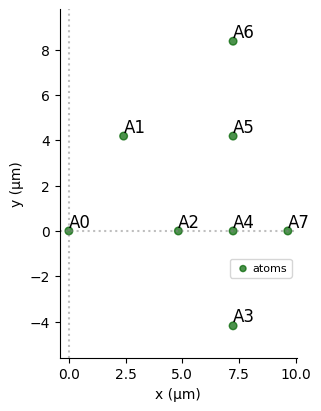

Counter({'10010010': 839,
         '10000011': 101,
         '01010000': 16,
         '01010010': 16,
         '00010010': 8,
         '10000001': 7,
         '10010100': 4,
         '00100010': 2,
         '01000011': 2,
         '10000010': 2,
         '00000011': 1,
         '10000000': 1,
         '10001010': 1})

In [6]:
# Run the MIS adiabatic solving function using the qubits dictionary
(reg, res) = MIS_adiabatic_solving(qubits_dict)

# Visualize the register of qubits
reg.draw()

# Display the measurement results sampled from the final quantum state
res

# Combining MIS problems to solve graph colouring problem

In [7]:
# List of colours for graph colouring; should cover most cases
colours = [
    'red', 'blue', 'green', 'yellow', 'cyan', 'magenta', 'black', 'white', 'gray', 'orange'
]

def dict_to_graph(qubits_dict):
    """
    Converts a dictionary of qubit positions into a graph representation.

    Args:
        qubits_dict (dict): Dictionary where keys are qubit names and values are coordinates.

    Returns:
        nx.Graph: A NetworkX graph where nodes are qubits and edges represent interference (distance ≤ 7).
    """
    # Initialize an empty graph
    G = nx.Graph()

    # List to store edges (connections between qubits)
    edges = []

    # Check pairwise distances between qubits to determine edges
    for i in range(len(qubits_dict)):
        for j in range(i + 1, len(qubits_dict)):
            # Add an edge if the distance between qubits is ≤ 7
            if np.linalg.norm(qubits_dict[f"A{i}"] - qubits_dict[f"A{j}"]) <= 7:
                edges.append((f"A{i}", f"A{j}"))

    # Add the edges to the graph
    G.add_edges_from(edges)
    return G


def solve_graph_colouring(coords, interference_length, config=None):
    """
    Solves the graph colouring problem using an MIS-based quantum adiabatic approach.

    Args:
        coords (list of tuples): List of physical coordinates of qubits [(x1, y1), (x2, y2), ...].
        interference_length (float): Physical distance threshold for interference between qubits.
        config (dict, optional): Configuration parameters for the quantum emulator.

    Returns:
        tuple: A tuple containing:
            - nx.Graph: The graph representation of the problem.
            - list: A list of colours for each node in the graph.
    """
    # Convert the physical coordinates into scaled qubit positions
    qubits_dict = physical_coords_to_atom_dict(coords, interference_length)

    # Create a graph from the qubit dictionary
    G = dict_to_graph(qubits_dict)

    # Initialize variables for graph colouring
    colour_index = 0  # Tracks the current colour being assigned
    colours_dict = {}  # Maps qubits to their assigned colours

    # Solve the colouring problem iteratively
    while len(qubits_dict) != 0:
        # Solve MIS (Maximum Independent Set) for the current qubits
        reg, res = MIS_adiabatic_solving(qubits_dict, config)

        # Get the most frequent result (state with the highest probability)
        res_string = res.most_common()[0][0]

        # Assign the current colour to qubits in the MIS
        for i in range(len(res_string)):
            if res_string[i] == "1":  # If the qubit is in the MIS
                colours_dict[reg.qubit_ids[i]] = colours[colour_index % len(colours)]
                qubits_dict.pop(reg.qubit_ids[i])  # Remove the qubit from the dictionary

        # Increment the colour index for the next round
        colour_index += 1

    # Map colours to the graph nodes for visualization
    graph_colours = [colours_dict.get(node, 'lightblue') for node in G.nodes]

    # Return the graph and the assigned colours
    return (G, graph_colours)

In [8]:
G, graph_colours = solve_graph_colouring(real_cords, 8.7)

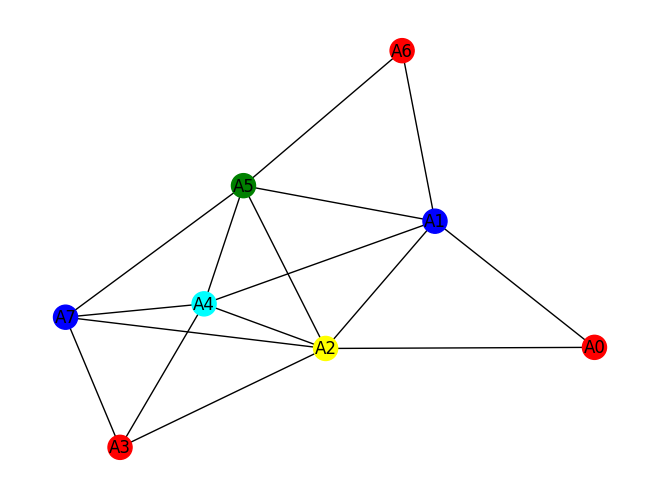

In [9]:
nx.draw(G, node_color=graph_colours, with_labels=True)

# Now MIS with noise

In [10]:
config = SimConfig(
    ("SPAM", "doppler", "amplitude"),  # Specifies the types of noise to simulate
    eta=0.05,  # Efficiency of the detection (probability of detecting a qubit correctly)
    epsilon=0.05,  # Probability of a false positive (detecting a qubit in the wrong state)
    epsilon_prime=0.05,  # Probability of a false negative (failing to detect a qubit in the correct state)
    temperature=30,  # Temperature of the system in microkelvins, which impacts Doppler noise
    runs=10,  # Number of independent simulation runs
    samples_per_run=100,  # Number of samples (measurements) taken in each simulation run
)


In [20]:
real_cords = [[0, 0], [3, 5.2], [6, 0], [9, -5.2], [9, 0], [9, 5.2], [9, 10.4], [12, 0]]
G, graph_colours = solve_graph_colouring(real_cords, 8.7,config)

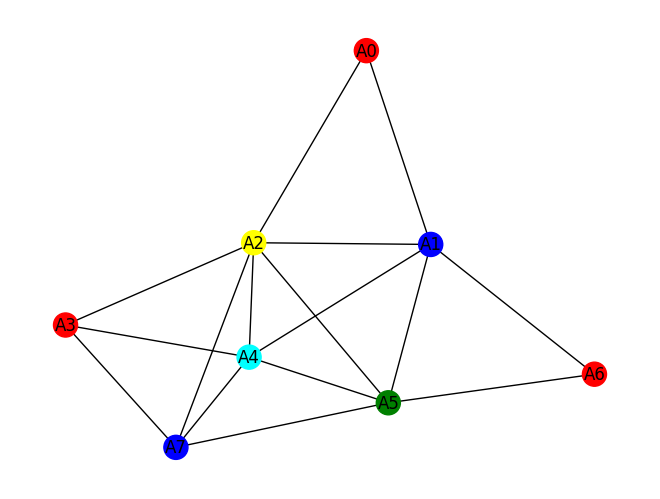

In [21]:
nx.draw(G, node_color=graph_colours, with_labels=True)